# Chokepoint Basket Backtest

**Framework**: find the non-obvious rate-limiting step in a widely-anticipated structural trend. The glamorous end (the car, the GPU, the headset) is usually overowned. The unglamorous prerequisite (the transformer, the coolant loop, the water permit) is where the mispricing lives.

**Sixteen themes tested:**

| # | Theme | Chokepoint basket | Glamour basket |
|---|-------|------------------|----------------|
| 1 | Grid before electrification | HUBB, ATKR, GEV, PWR | TSLA, RIVN |
| 2 | Cooling before compute density | MOD, FIX, VRT | NVDA, AMD |
| 3 | Bandwidth before spatial computing | CALX, PCTEL | META, AAPL |
| 4 | Water before data centres | ERII, ITRI, WTS | MSFT, GOOGL |
| 5 | Skilled labour before reshoring | LINC, KFRC, NSP | INTC, TSM |
| 6 | Inference efficiency before AGI | CEVA | NVDA |
| 7 | Copper before clean energy | FCX, SCCO, TECK | NEE, ENPH, FSLR |
| 8 | Lithium before EVs | ALB, SQM | TSLA, GM, F |
| 9 | Defence MRO before rearmament | TDG, HEI | LMT, RTX |
| 10 | Tankers before energy fragmentation | FRO, INSW, NAT | XOM, CVX |
| 11 | Nuclear fuel before nuclear renaissance | CCJ, LEU, UEC | CEG, VST |
| 12 | Semiconductor test before fab buildout | COHU, ONTO, KLIC | INTC, MU |
| 13 | Specialty gases before chip/clean expansion | LIN, APD | NVDA, NEE |
| 14 | Agricultural inputs before food security | MOS, CF, NTR | ADM, BG |
| 15 | Timber before housing undersupply | WY, RYN | LEN, TOL |
| 16 | Wealth platform infra before great wealth transfer | SEIC, ENV | SCHW, MS |

**Methodology**: equal-weight baskets, monthly rebalancing, adjusted-close total returns.  
**Two P&L series per theme**: (a) long chokepoint vs SPY, (b) long chokepoint / short glamour dollar-neutral spread.  
**Date range**: 2015-01-01 → today (or earliest available per ticker).

In [1]:
import math
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")

# Bloomberg-ish palette
AMBER  = "#FA8C00"
CYAN   = "#00D9FF"
GREEN  = "#4CFF4C"
PURPLE = "#BE85FF"
RED    = "#FF4C4C"
YELLOW = "#FFE14C"
BG     = "#000000"
FG     = "#E8E8E8"
GRID   = "#333333"

THEME_COLORS = [
    "#FA8C00", "#00D9FF", "#4CFF4C", "#BE85FF", "#FF4C4C", "#FFE14C",
    "#FF9EC6", "#9EFFCB", "#FFB74C", "#4C9EFF", "#FF6B6B", "#C8FF4C",
    "#FF4CFF", "#4CFFFF", "#FFA04C", "#8080FF",
]

START = "2015-01-01"
END   = dt.date.today().isoformat()

THEMES = [
    # --- originally AI-adjacent ---
    {
        "name": "Grid before electrification",
        "choke": ["HUBB", "ATKR", "GEV", "PWR"],
        "glam":  ["TSLA", "RIVN"],
    },
    {
        "name": "Cooling before compute density",
        "choke": ["MOD", "FIX", "VRT"],
        "glam":  ["NVDA", "AMD"],
    },
    {
        "name": "Bandwidth before spatial computing",
        "choke": ["CALX", "PCTEL"],
        "glam":  ["META", "AAPL"],
    },
    {
        "name": "Water before data centres",
        "choke": ["ERII", "ITRI", "WTS"],
        "glam":  ["MSFT", "GOOGL"],
    },
    {
        "name": "Skilled labour before reshoring",
        "choke": ["LINC", "KFRC", "NSP"],
        "glam":  ["INTC", "TSM"],
    },
    {
        "name": "Inference efficiency before AGI",
        "choke": ["CEVA"],
        "glam":  ["NVDA"],
    },
    # --- broader structural themes ---
    {
        "name": "Copper before clean energy",
        "choke": ["FCX", "SCCO", "TECK"],
        "glam":  ["NEE", "ENPH", "FSLR"],
    },
    {
        "name": "Lithium before EVs",
        "choke": ["ALB", "SQM"],
        "glam":  ["TSLA", "GM", "F"],
    },
    {
        "name": "Defence MRO before rearmament",
        "choke": ["TDG", "HEI"],
        "glam":  ["LMT", "RTX"],
    },
    {
        "name": "Tankers before energy fragmentation",
        "choke": ["FRO", "INSW", "NAT"],
        "glam":  ["XOM", "CVX"],
    },
    {
        "name": "Nuclear fuel before nuclear renaissance",
        "choke": ["CCJ", "LEU", "UEC"],
        "glam":  ["CEG", "VST"],
    },
    {
        "name": "Semiconductor test before fab buildout",
        "choke": ["COHU", "ONTO", "KLIC"],
        "glam":  ["INTC", "MU"],
    },
    {
        "name": "Specialty gases before chip/clean expansion",
        "choke": ["LIN", "APD"],
        "glam":  ["NVDA", "NEE"],
    },
    {
        "name": "Agricultural inputs before food security",
        "choke": ["MOS", "CF", "NTR"],
        "glam":  ["ADM", "BG"],
    },
    {
        "name": "Timber before housing undersupply",
        "choke": ["WY", "RYN"],
        "glam":  ["LEN", "TOL"],
    },
    {
        "name": "Wealth platform infra before great wealth transfer",
        "choke": ["SEIC", "ENV"],
        "glam":  ["SCHW", "MS"],
    },
]

ALL_TICKERS = sorted(set(
    ["SPY"]
    + [t for th in THEMES for t in th["choke"]]
    + [t for th in THEMES for t in th["glam"]]
))
print(f"Fetching {len(ALL_TICKERS)} tickers across {len(THEMES)} themes")

Fetching 70 tickers across 16 themes


In [2]:
raw = yf.download(
    ALL_TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=True,
)

# Flatten multi-level columns if needed
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw[["Close"]].copy()

prices = prices.dropna(how="all")
print(f"Price matrix: {prices.shape[0]} days × {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing data (first available date per ticker):")
for t in ALL_TICKERS:
    if t in prices.columns:
        first = prices[t].first_valid_index()
        pct_missing = prices[t].isna().mean() * 100
        if pct_missing > 1 or (first is not None and first.year > 2015):
            print(f"  {t:6s}  first={first.date() if first else 'N/A'}  missing={pct_missing:.1f}%")
    else:
        print(f"  {t:6s}  NOT FOUND")

[**********************53%                       ]  37 of 70 completed$ENV: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PCTEL"}}}
[**********************64%******                 ]  45 of 70 completed$PCTEL: possibly delisted; no timezone found
[*********************100%***********************]  70 of 70 completed

2 Failed downloads:
['ENV', 'PCTEL']: possibly delisted; no timezone found


Price matrix: 2844 days × 70 tickers
Date range: 2015-01-02 → 2026-04-24

Missing data (first available date per ticker):
  ATKR    first=2016-06-10  missing=12.7%
  CEG     first=2022-01-19  missing=62.4%
  ENV     first=N/A  missing=100.0%
  GEV     first=2024-03-27  missing=81.7%
  INSW    first=2016-11-16  missing=16.6%
  NTR     first=2018-01-02  missing=26.5%
  ONTO    first=2019-10-28  missing=42.7%
  PCTEL   first=N/A  missing=100.0%
  RIVN    first=2021-11-10  missing=60.7%
  VRT     first=2018-08-02  missing=31.7%
  VST     first=2016-10-05  missing=15.6%


In [3]:
# Resample to month-end and compute simple monthly returns
monthly = prices.resample("ME").last()
rets = monthly.pct_change().dropna(how="all")

def basket_returns(tickers: list[str], rets_df: pd.DataFrame) -> pd.Series:
    """Equal-weight mean of available tickers each month."""
    cols = [t for t in tickers if t in rets_df.columns]
    return rets_df[cols].mean(axis=1)

def cum_ret(r: pd.Series) -> pd.Series:
    return (1 + r).cumprod()

def sharpe(r: pd.Series, freq: int = 12) -> float:
    if r.std() == 0:
        return np.nan
    return (r.mean() / r.std()) * np.sqrt(freq)

def max_dd(r: pd.Series) -> float:
    cr = cum_ret(r)
    return float((cr / cr.cummax() - 1).min())

def ann_ret(r: pd.Series, freq: int = 12) -> float:
    n = len(r)
    if n == 0:
        return np.nan
    return float((1 + r).prod() ** (freq / n) - 1)

# Build all series
spy_r = rets["SPY"].dropna()

results = []
for th in THEMES:
    choke_r = basket_returns(th["choke"], rets)
    glam_r  = basket_returns(th["glam"], rets)
    ls_r    = choke_r - glam_r  # dollar-neutral long/short spread

    # Align all to common dates where choke is available
    idx = choke_r.dropna().index

    results.append({
        "name":    th["name"],
        "choke":   choke_r.loc[idx],
        "glam":    glam_r.loc[idx],
        "ls":      ls_r.loc[idx],
        "spy":     spy_r.reindex(idx).fillna(0),
    })

print("Series built for all themes.")

Series built for all themes.


## Long-only: Chokepoint baskets vs SPY

Each panel shows the cumulative return of the equal-weight chokepoint basket (amber) and SPY (grey). Monthly rebalancing, no transaction costs.

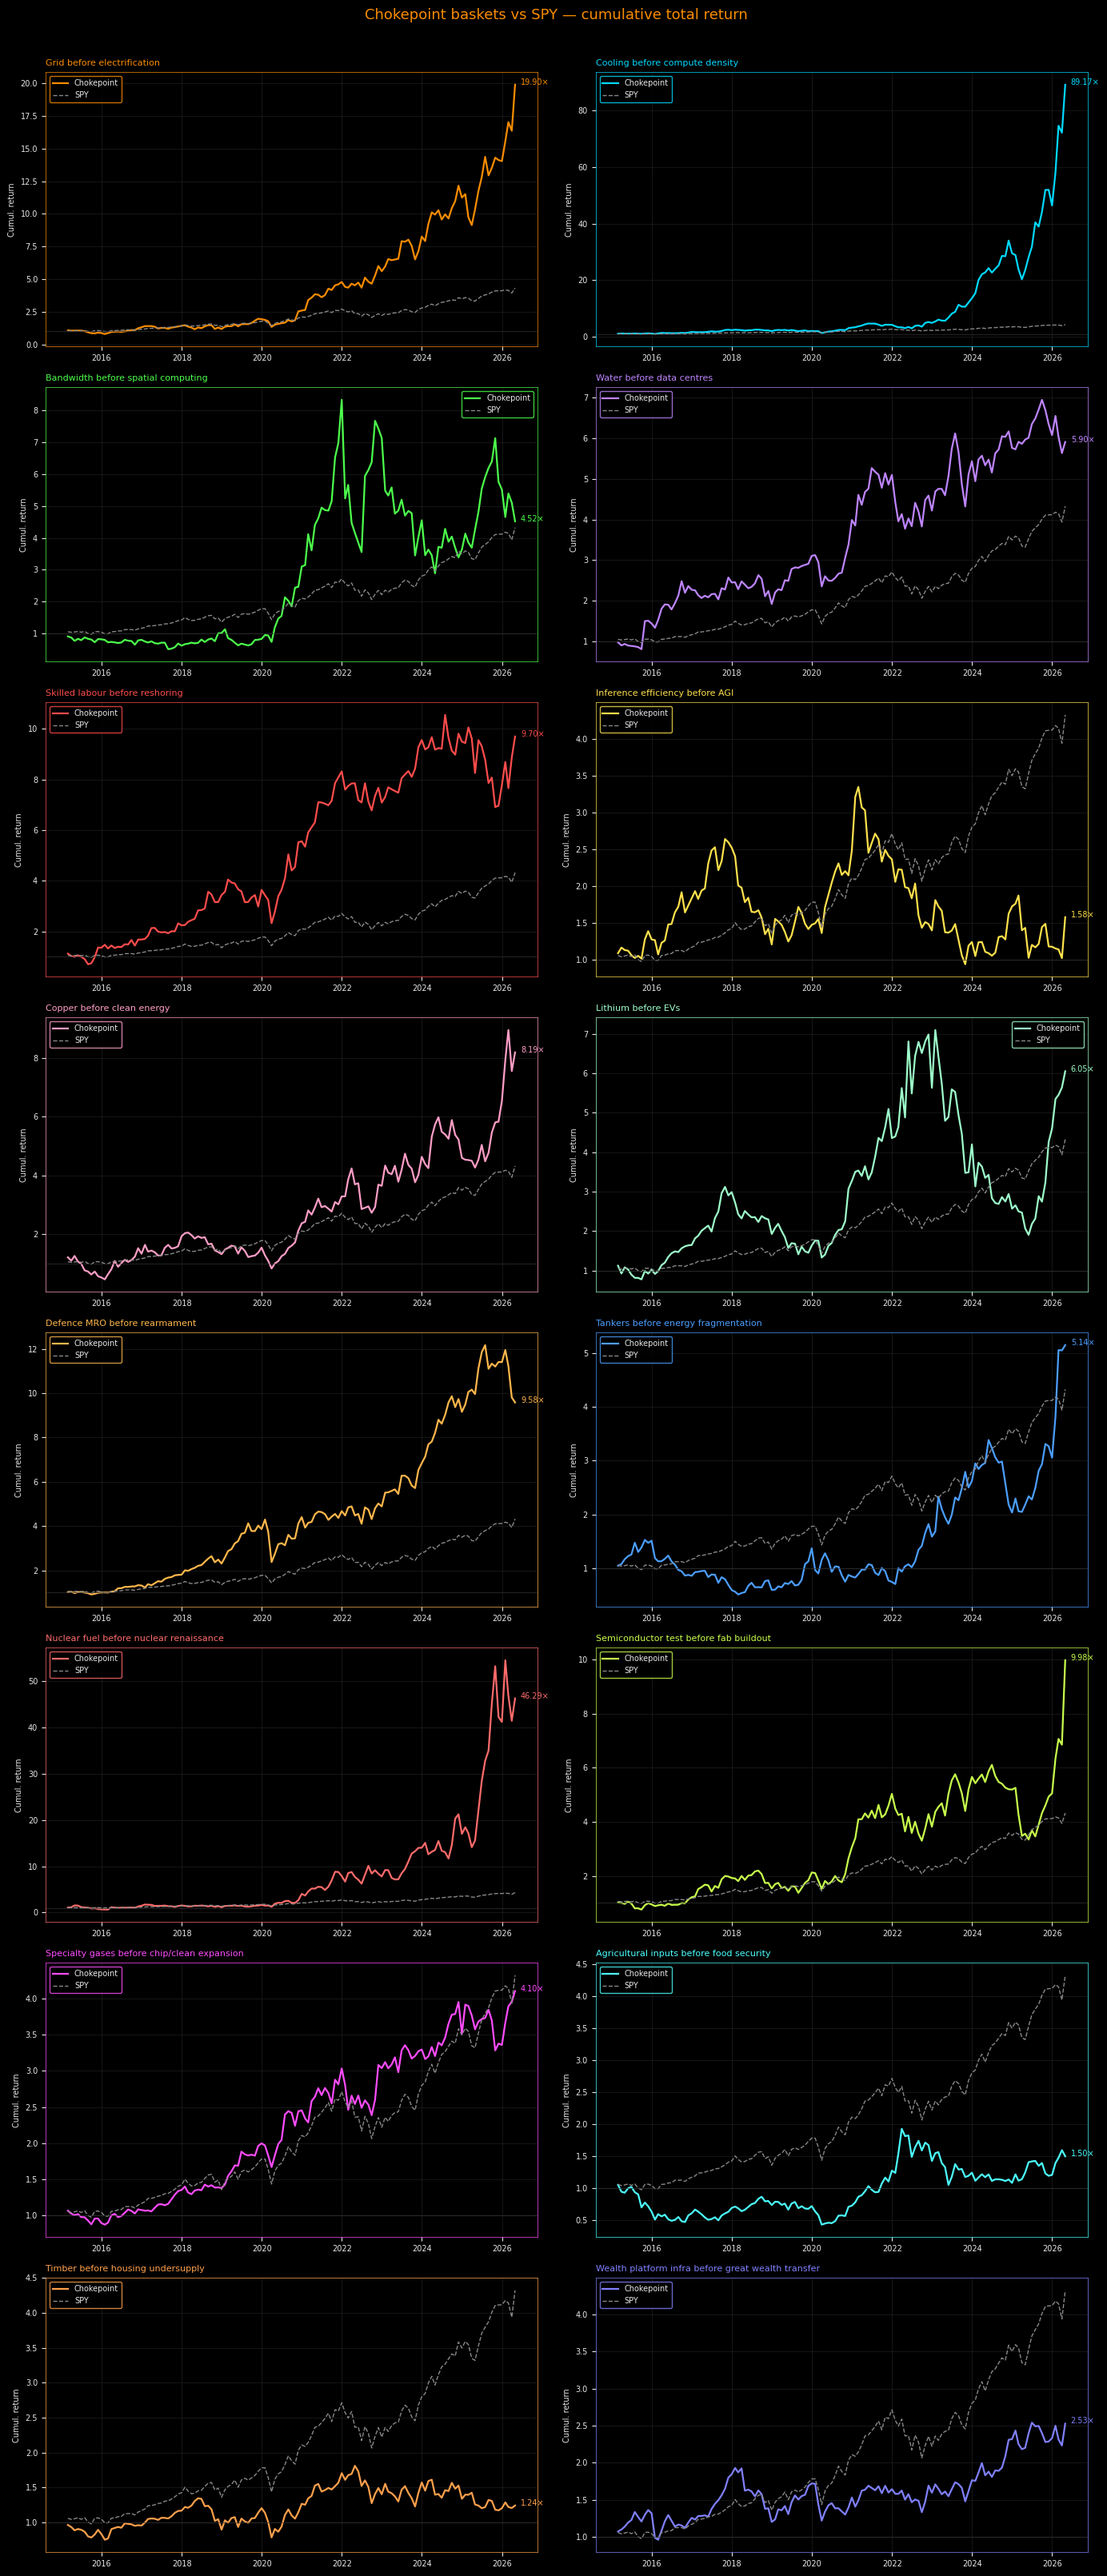

In [4]:
ncols = 2
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), facecolor=BG)
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    color = THEME_COLORS[i % len(THEME_COLORS)]
    ax.set_facecolor(BG)

    cr_choke = cum_ret(res["choke"])
    cr_spy   = cum_ret(res["spy"])

    ax.plot(cr_choke.index, cr_choke.values, color=color,    linewidth=1.6, label="Chokepoint")
    ax.plot(cr_spy.index,   cr_spy.values,   color="#888888", linewidth=1.0, linestyle="--", label="SPY")

    ax.axhline(1.0, color=GRID, linewidth=0.5)
    ax.set_title(res["name"], color=color, fontsize=8, loc="left")
    ax.tick_params(colors=FG, labelsize=7)
    ax.set_ylabel("Cumul. return", color=FG, fontsize=7)
    ax.grid(color=GRID, alpha=0.4)
    for s in ax.spines.values():
        s.set_color(color)
        s.set_linewidth(0.5)
    ax.legend(facecolor=BG, edgecolor=color, labelcolor=FG, fontsize=7)
    ax.annotate(
        f"{cr_choke.iloc[-1]:.2f}×",
        xy=(cr_choke.index[-1], cr_choke.iloc[-1]),
        xytext=(5, 0), textcoords="offset points",
        color=color, fontsize=7,
    )

# Hide unused axes
for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Chokepoint baskets vs SPY — cumulative total return",
             color=AMBER, fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## Long chokepoint / short glamour — dollar-neutral spread

Each panel shows `chokepoint_basket − glamour_basket` cumulated. Positive = chokepoint outperformed glamour. This is the pure expression of the "mispricing lives in the unglamorous prerequisite" thesis.

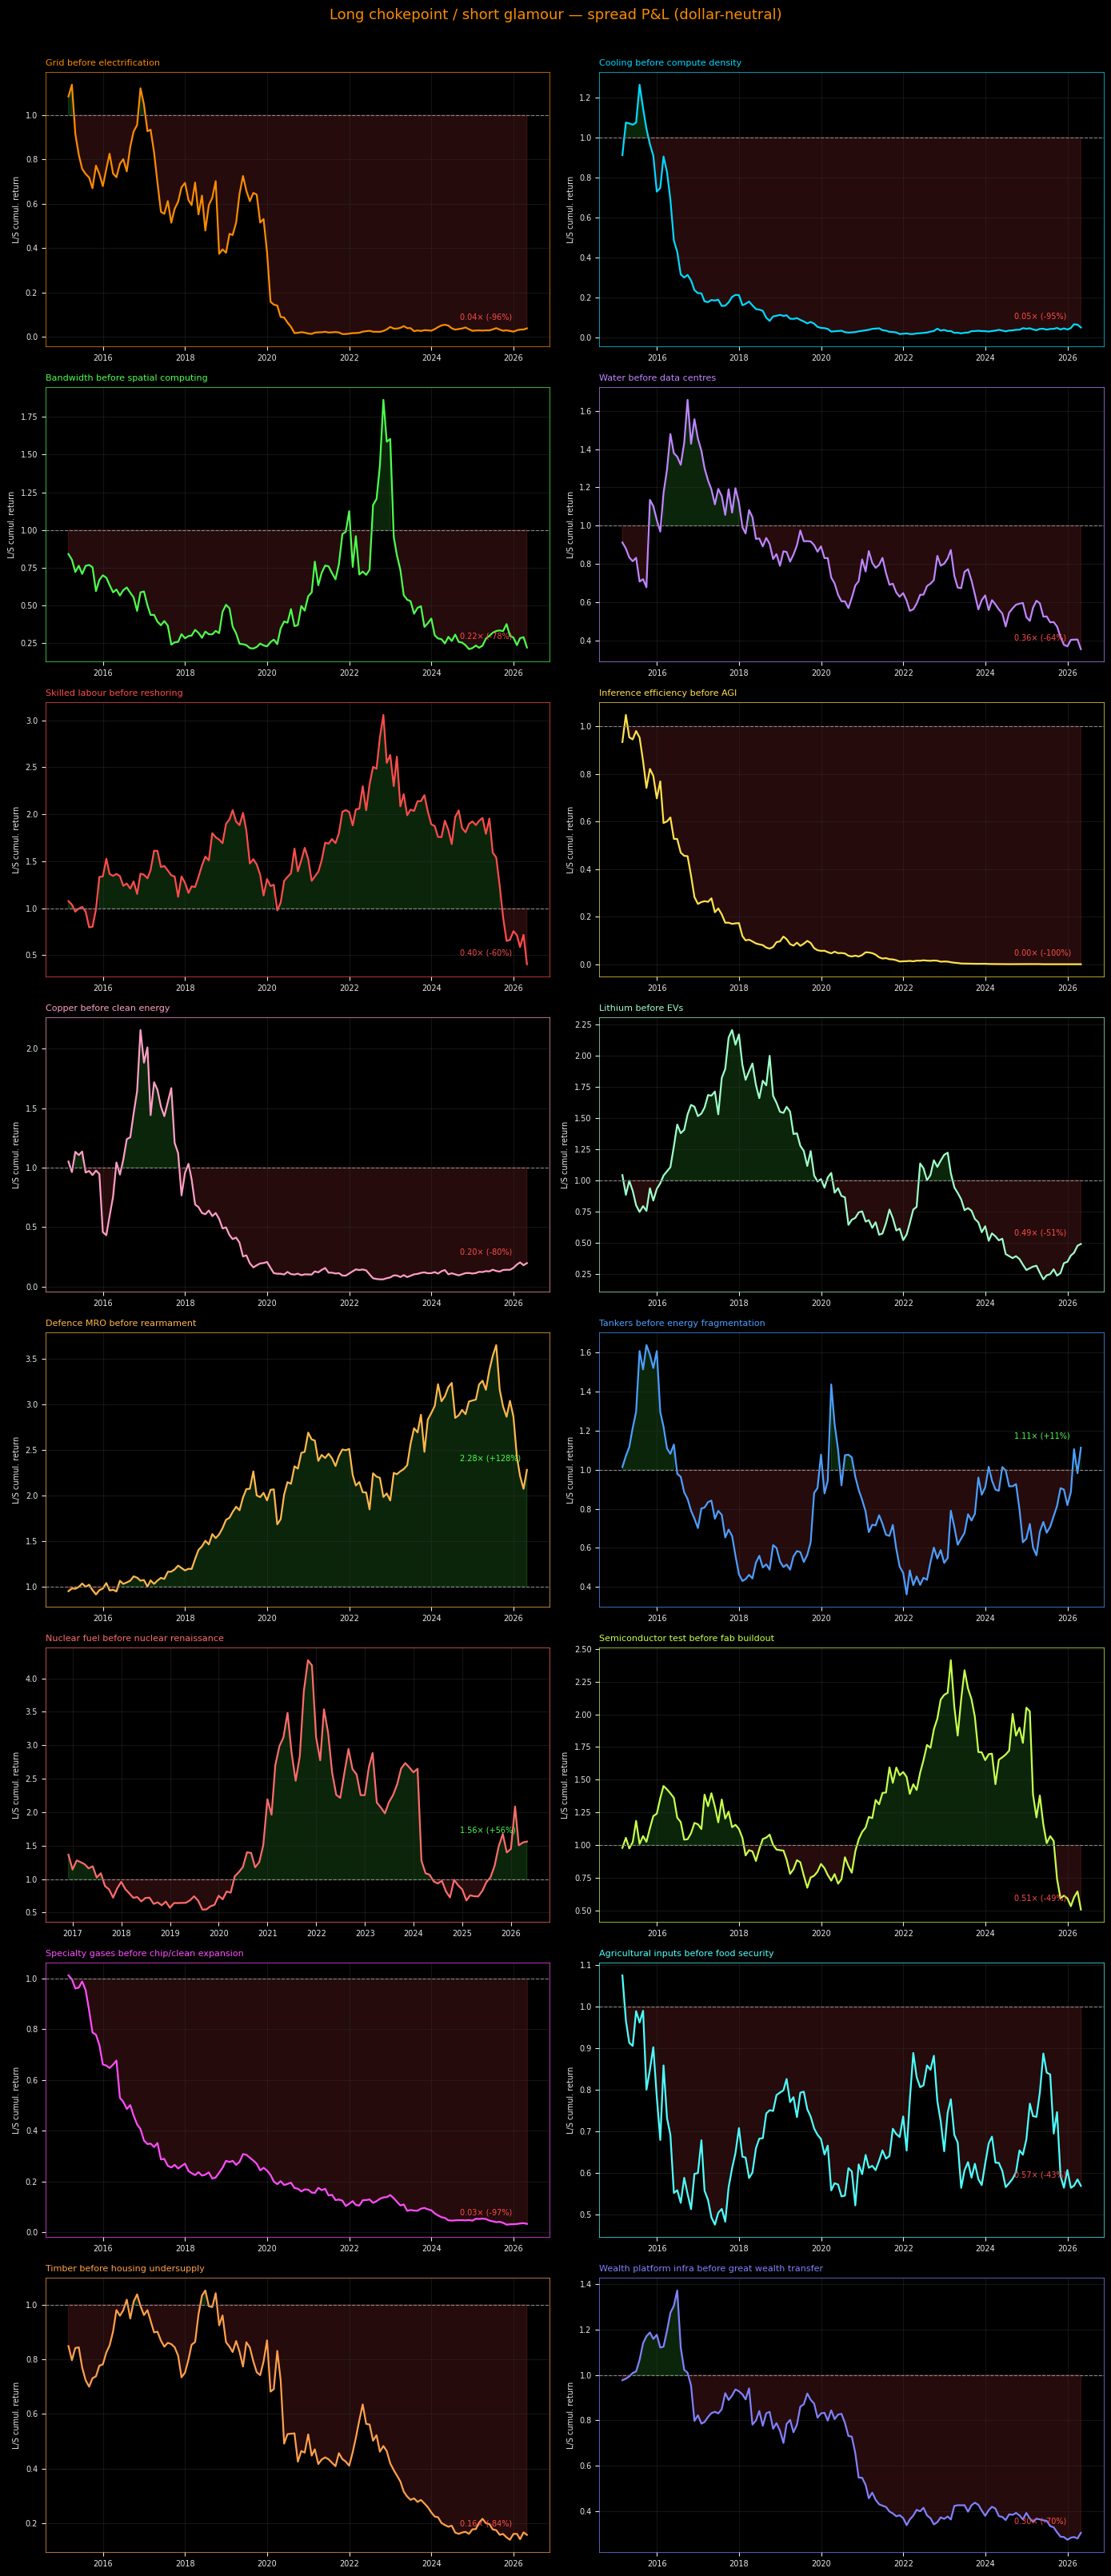

In [5]:
ncols = 2
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), facecolor=BG)
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    color = THEME_COLORS[i % len(THEME_COLORS)]
    ax.set_facecolor(BG)

    ls_cum = (1 + res["ls"]).cumprod()

    ax.plot(ls_cum.index, ls_cum.values, color=color, linewidth=1.6)
    ax.fill_between(
        ls_cum.index, 1.0, ls_cum.values,
        where=(ls_cum.values >= 1.0), alpha=0.15, color=GREEN,
    )
    ax.fill_between(
        ls_cum.index, 1.0, ls_cum.values,
        where=(ls_cum.values < 1.0), alpha=0.15, color=RED,
    )
    ax.axhline(1.0, color="#888888", linewidth=0.8, linestyle="--")

    ax.set_title(res["name"], color=color, fontsize=8, loc="left")
    ax.tick_params(colors=FG, labelsize=7)
    ax.set_ylabel("L/S cumul. return", color=FG, fontsize=7)
    ax.grid(color=GRID, alpha=0.4)
    for s in ax.spines.values():
        s.set_color(color)
        s.set_linewidth(0.5)

    final = ls_cum.iloc[-1]
    label = f"{final:.2f}× ({'+' if final >= 1 else ''}{(final-1)*100:.0f}%)"
    ax.annotate(
        label,
        xy=(ls_cum.index[-1], final),
        xytext=(-60, 8), textcoords="offset points",
        color=GREEN if final >= 1 else RED, fontsize=7,
    )

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Long chokepoint / short glamour — spread P&L (dollar-neutral)",
             color=AMBER, fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## Individual equity curves — all tickers

Chokepoint names (amber) vs glamour names (red), normalised to 1 at first available date.

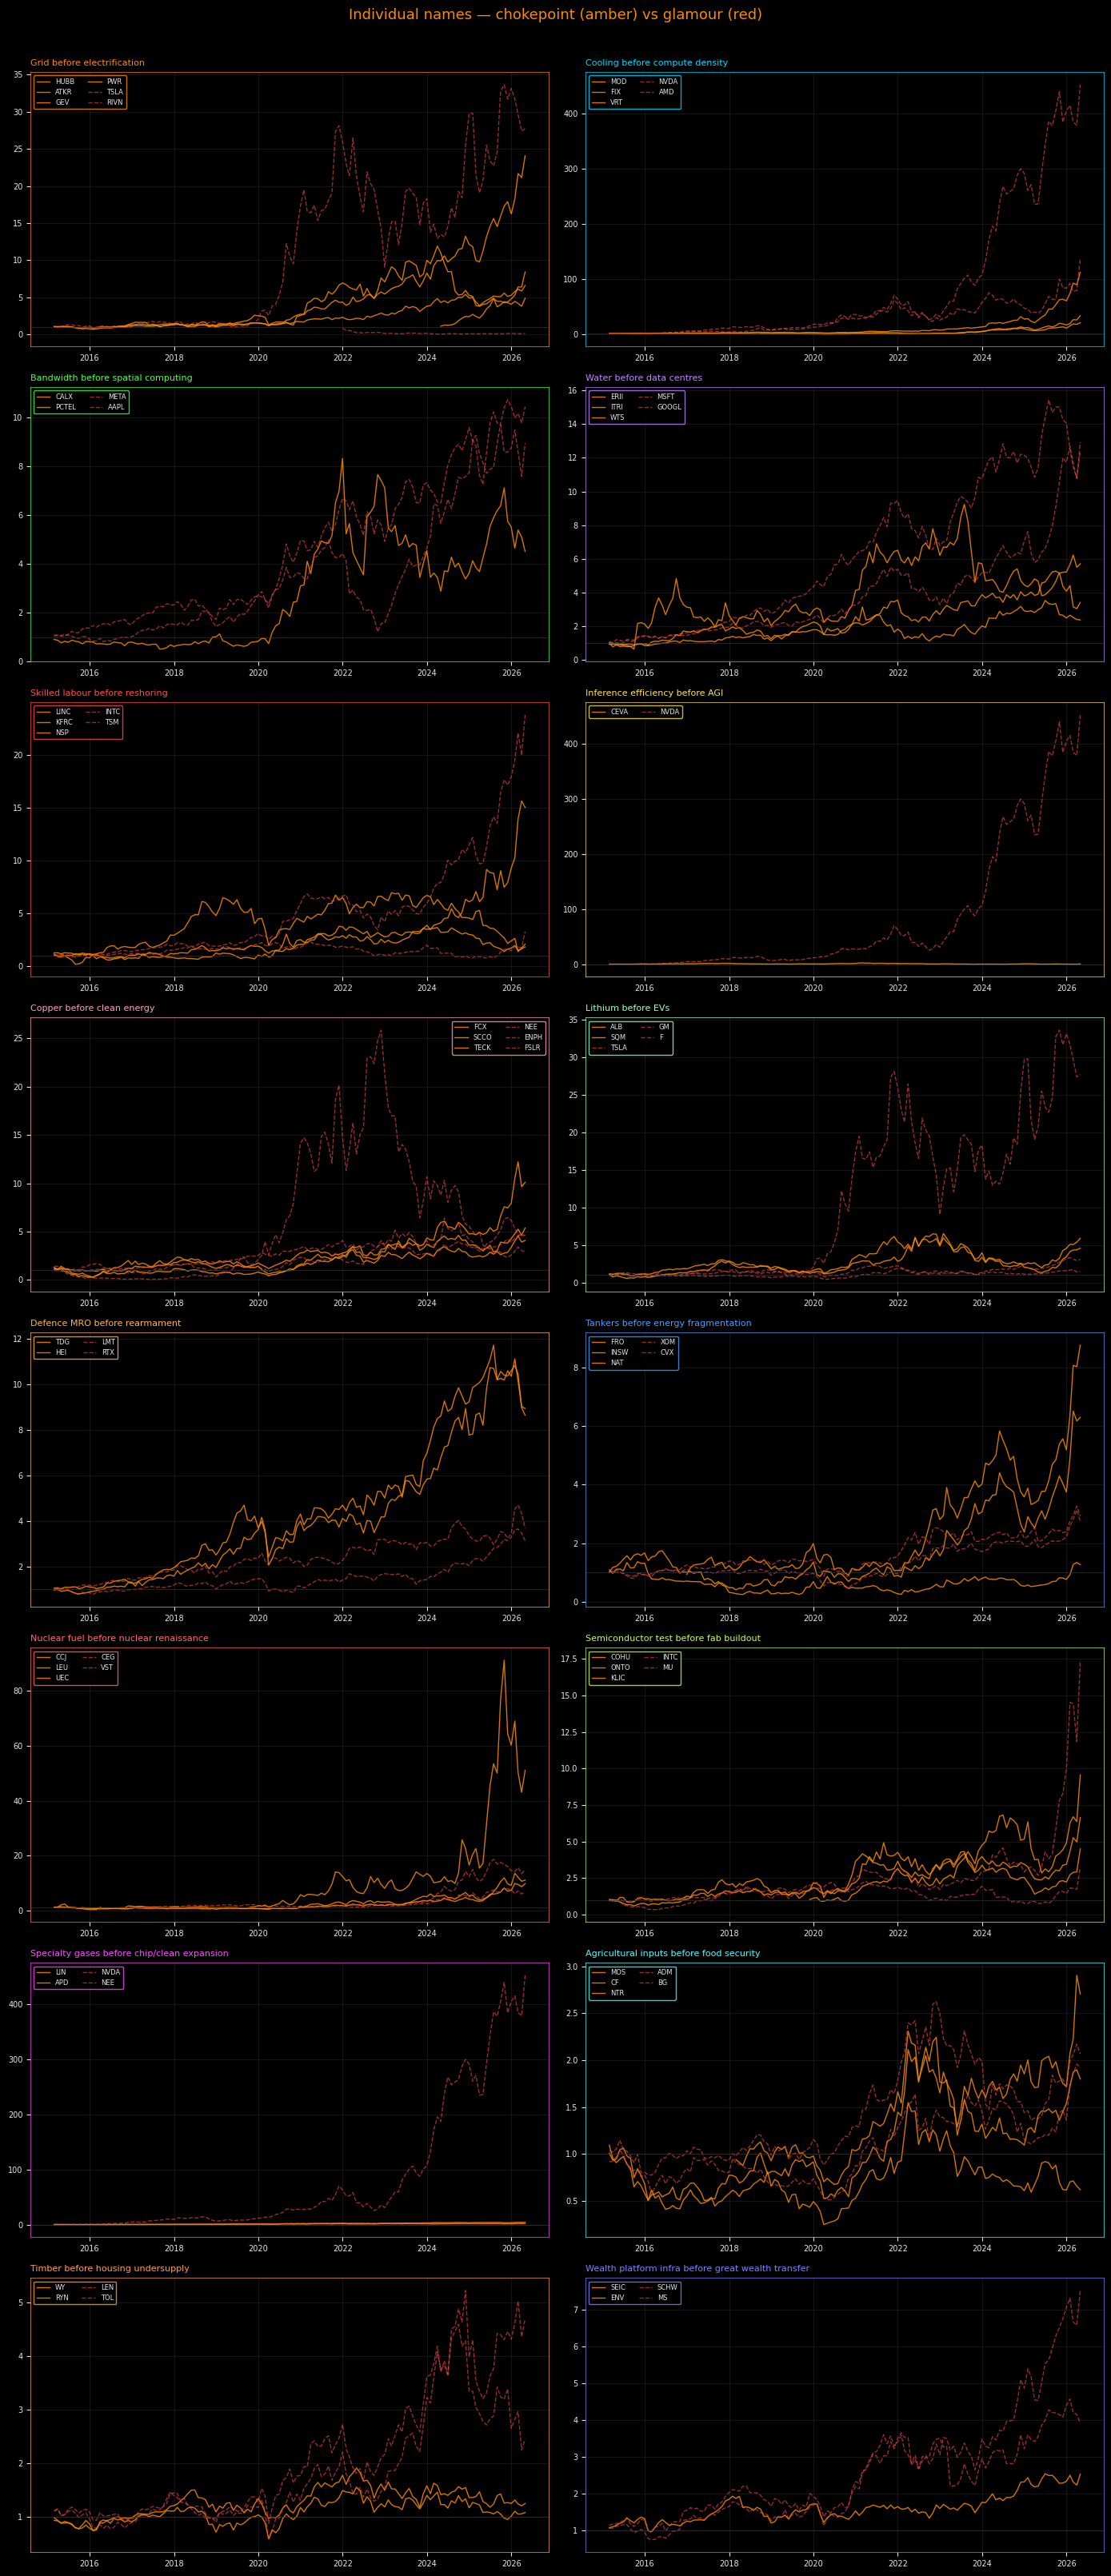

In [6]:
ncols = 2
nrows = math.ceil(len(THEMES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), facecolor=BG)
axes = axes.flatten()

for i, (th, ax) in enumerate(zip(THEMES, axes)):
    color = THEME_COLORS[i % len(THEME_COLORS)]
    ax.set_facecolor(BG)

    for t in th["choke"]:
        if t not in rets.columns:
            continue
        cr = cum_ret(rets[t].dropna())
        ax.plot(cr.index, cr.values, color=AMBER, linewidth=1.0, alpha=0.85, label=t)

    for t in th["glam"]:
        if t not in rets.columns:
            continue
        cr = cum_ret(rets[t].dropna())
        ax.plot(cr.index, cr.values, color=RED, linewidth=1.0, alpha=0.6, linestyle="--", label=t)

    ax.axhline(1.0, color=GRID, linewidth=0.5)
    ax.set_title(th["name"], color=color, fontsize=8, loc="left")
    ax.tick_params(colors=FG, labelsize=7)
    ax.grid(color=GRID, alpha=0.4)
    for s in ax.spines.values():
        s.set_color(color)
        s.set_linewidth(0.5)
    ax.legend(facecolor=BG, edgecolor=color, labelcolor=FG, fontsize=6, ncol=2)

for j in range(len(THEMES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Individual names — chokepoint (amber) vs glamour (red)",
             color=AMBER, fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## Summary statistics

In [7]:
rows = []
spy_full = spy_r

for res in results:
    choke_r = res["choke"]
    glam_r  = res["glam"]
    ls_r    = res["ls"]
    spy_al  = res["spy"]

    # Beta-adjusted excess return vs SPY
    cov = np.cov(choke_r.values, spy_al.values)
    beta = cov[0, 1] / cov[1, 1] if cov[1, 1] > 0 else np.nan
    alpha_ann = ann_ret(choke_r - beta * spy_al) if not np.isnan(beta) else np.nan

    rows.append({
        "Theme":                  res["name"],
        "Start":                  choke_r.index[0].strftime("%Y-%m"),
        "Choke Ann Ret":          f"{ann_ret(choke_r)*100:+.1f}%",
        "Glam Ann Ret":           f"{ann_ret(glam_r)*100:+.1f}%",
        "SPY Ann Ret":            f"{ann_ret(spy_al)*100:+.1f}%",
        "Choke Sharpe":           f"{sharpe(choke_r):.2f}",
        "Choke Max DD":           f"{max_dd(choke_r)*100:.1f}%",
        "L/S Ann Ret":            f"{ann_ret(ls_r)*100:+.1f}%",
        "L/S Sharpe":             f"{sharpe(ls_r):.2f}",
        "L/S Max DD":             f"{max_dd(ls_r)*100:.1f}%",
        "Beta vs SPY":            f"{beta:.2f}" if not np.isnan(beta) else "N/A",
        "Alpha (ann)": f"{alpha_ann*100:+.1f}%" if not np.isnan(alpha_ann) else "N/A",
    })

summary = pd.DataFrame(rows).set_index("Theme")

# Styled display
pd.set_option("display.max_colwidth", None)
summary

,Start,Choke Ann Ret,Glam Ann Ret,SPY Ann Ret,Choke Sharpe,Choke Max DD,L/S Ann Ret,L/S Sharpe,L/S Max DD,Beta vs SPY,Alpha (ann)
Theme,,,,,,,,,,,
Grid before electrification,2015-02,+30.5%,+25.9%,+13.9%,1.03,-31.7%,-25.1%,-0.15,-98.9%,1.41,+9.3%
Cooling before compute density,2015-02,+49.1%,+68.1%,+13.9%,1.21,-46.8%,-23.3%,-0.34,-98.6%,1.69,+21.6%
Bandwidth before spatial computing,2015-02,+14.3%,+24.3%,+13.9%,0.50,-65.3%,-12.6%,0.02,-88.8%,1.31,-3.9%
Water before data centres,2015-02,+17.1%,+26.0%,+13.9%,0.59,-29.3%,-8.8%,-0.12,-78.5%,1.38,-1.9%
Skilled labour before reshoring,2015-02,+22.4%,+24.1%,+13.9%,0.76,-42.6%,-7.7%,-0.00,-86.8%,1.04,+7.0%
Inference efficiency before AGI,2015-02,+4.1%,+72.2%,+13.9%,0.30,-72.0%,-49.4%,-1.10,-100.0%,1.47,-13.8%
Copper before clean energy,2015-02,+20.6%,+22.4%,+13.9%,0.65,-63.5%,-13.4%,-0.01,-97.2%,1.40,+1.0%
Lithium before EVs,2015-02,+17.3%,+20.0%,+13.9%,0.59,-73.1%,-6.2%,0.01,-90.7%,1.26,-0.1%
Defence MRO before rearmament,2015-02,+22.2%,+12.2%,+13.9%,0.94,-44.7%,+7.6%,0.45,-43.2%,1.11,+6.1%


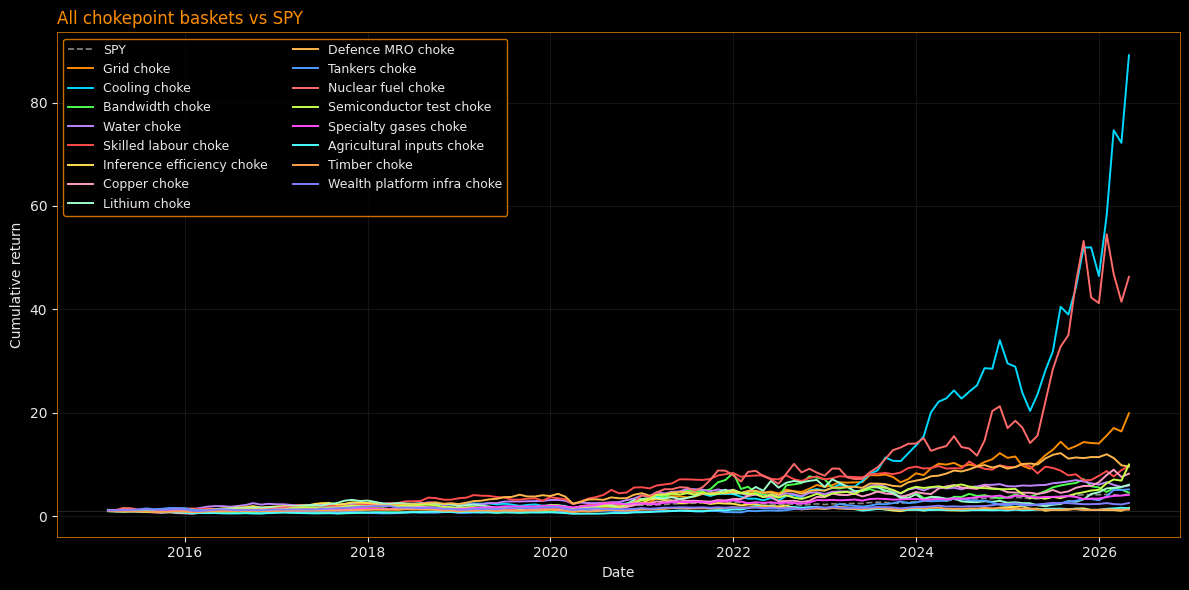

In [8]:
# Combined overlay — all chokepoint baskets on one chart
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

cr_spy_full = cum_ret(spy_r)
ax.plot(cr_spy_full.index, cr_spy_full.values,
        color="#888888", linewidth=1.2, linestyle="--", label="SPY", zorder=2)

for i, res in enumerate(results):
    color = THEME_COLORS[i]
    cr = cum_ret(res["choke"])
    short_name = res["name"].split(" before ")[0]
    ax.plot(cr.index, cr.values, color=color, linewidth=1.4,
            label=f"{short_name} choke", zorder=3)

ax.axhline(1.0, color=GRID, linewidth=0.5)
ax.set_xlabel("Date", color=FG)
ax.set_ylabel("Cumulative return", color=FG)
ax.set_title("All chokepoint baskets vs SPY", color=AMBER, loc="left", fontsize=12)
ax.tick_params(colors=FG)
ax.grid(color=GRID, alpha=0.4)
for s in ax.spines.values():
    s.set_color(AMBER)
    s.set_linewidth(0.5)
ax.legend(facecolor=BG, edgecolor=AMBER, labelcolor=FG, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

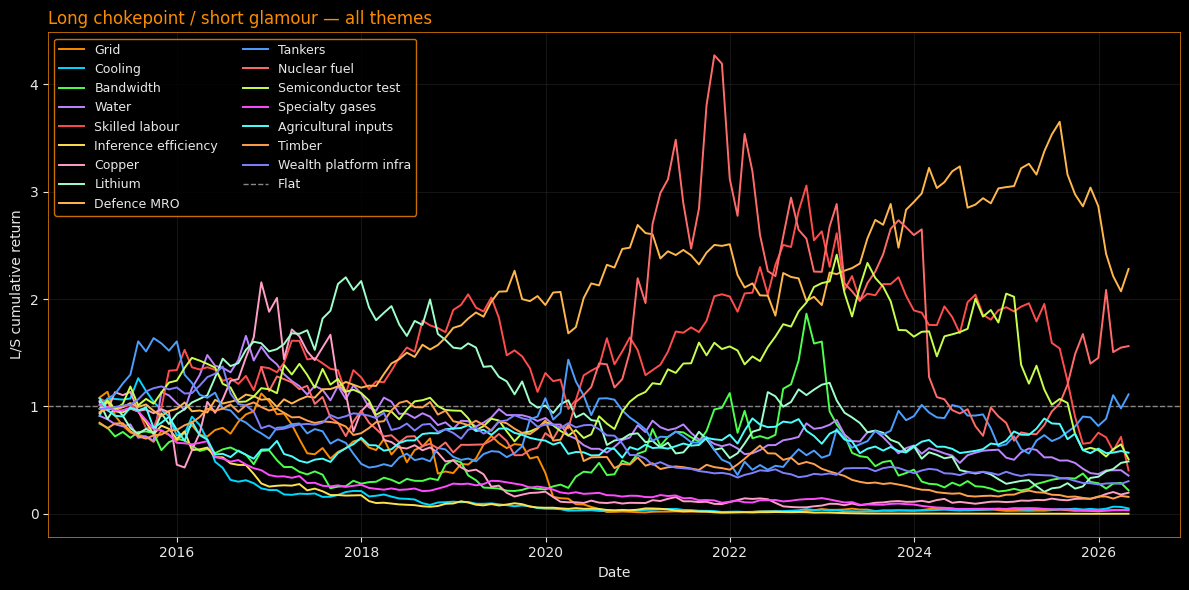

In [9]:
# Combined overlay — all long/short spreads
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

for i, res in enumerate(results):
    color = THEME_COLORS[i]
    ls_cum = (1 + res["ls"]).cumprod()
    short_name = res["name"].split(" before ")[0]
    ax.plot(ls_cum.index, ls_cum.values, color=color, linewidth=1.4,
            label=short_name, zorder=3)

ax.axhline(1.0, color="#888888", linewidth=1.0, linestyle="--", label="Flat")
ax.set_xlabel("Date", color=FG)
ax.set_ylabel("L/S cumulative return", color=FG)
ax.set_title("Long chokepoint / short glamour — all themes", color=AMBER, loc="left", fontsize=12)
ax.tick_params(colors=FG)
ax.grid(color=GRID, alpha=0.4)
for s in ax.spines.values():
    s.set_color(AMBER)
    s.set_linewidth(0.5)
ax.legend(facecolor=BG, edgecolor=AMBER, labelcolor=FG, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()